<a href="https://colab.research.google.com/github/OscarEdy/Proyecto-Ciencia-de-Datos/blob/main/Proyecto_final_de_CD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ANALISIS DEL CUBO DE VENTAS DEL PERIODO 2025 DE UNA EMPRESA DISTRIBUIDORA DE LA MARCA NESTLE

*   OSCAR EDY VILCA QUISPE
*   RODRIGO BERNARDO CONDORI GUTIERREZ




**PASO 1 — Importar librerías**

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**PASO 2 — Cargar el archivo**

In [9]:
# Importamos la librería que permite conectar Google Drive con Colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
# Leemos el archivo CSV desde Google Drive
df = pd.read_csv('/content/drive/MyDrive/CD/ventas2025.csv', sep=';', on_bad_lines='warn')

**PASO** 3 — Ver la **estructura**

In [11]:
# verificamos que la data

df.head()

,Periodo_Año,Periodo_Mes,Documento_Estado,Pedido,Documento_Fecha,Documento_tipo,Documento_Serie,Documento_Numero,Cliente_Codigo,Cliente_Documento,...,IDItemComprobante,Agrupacion,Importe_ValorVenta,Cliente_Provincia,Cliente_Departamento,Vendedor_CodRuta,Producto_UME,ItemSaldo,CodigoSucursal,Sucursal
0,2025,1,ACTIVO,ComprobanteVenta/ B301-0021581,00:00.0,07 Nota de Crédito,B301,21581,6798,1874922,...,0,0,-12.423729,EL COLLAO,PUNO,107.0,-0.2700,0.0,1,CENTRAL
1,2025,1,ACTIVO,Pedido/ B301-0924174,00:00.0,03 Boleta de Venta,B301,924174,9690,46903487,...,0,0,0.000000,SAN ROMAN,PUNO,NaN,0.0180,0.0,1,CENTRAL
2,2025,1,ACTIVO,Pedido/ B301-0924174,00:00.0,03 Boleta de Venta,B301,924174,9690,46903487,...,0,0,28.000000,SAN ROMAN,PUNO,NaN,0.6000,0.0,1,CENTRAL
3,2025,1,ACTIVO,Pedido/ B301-0924174,00:00.0,03 Boleta de Venta,B301,924174,9690,46903487,...,0,0,25.923729,SAN ROMAN,PUNO,NaN,0.5400,0.0,1,CENTRAL
4,2025,1,ACTIVO,Pedido/ B301-0924177,00:00.0,03 Boleta de Venta,B301,924177,9401,41542702,...,0,0,11.677966,SAN ROMAN,PUNO,NaN,0.0128,0.0,1,CENTRAL


In [12]:
# Mostramos cantidad de filas, cantidad de columnas, tipos de datos y valores nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 451793 entries, 0 to 451792
Data columns (total 51 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Periodo_Año            451793 non-null  int64  
 1   Periodo_Mes            451793 non-null  int64  
 2   Documento_Estado       451793 non-null  object 
 3   Pedido                 451793 non-null  object 
 4   Documento_Fecha        451793 non-null  object 
 5   Documento_tipo         451793 non-null  object 
 6   Documento_Serie        451793 non-null  object 
 7   Documento_Numero       451793 non-null  int64  
 8   Cliente_Codigo         451793 non-null  object 
 9   Cliente_Documento      451793 non-null  int64  
 10  Cliente_Distrito       451793 non-null  object 
 11  Cliente_Categoria      451793 non-null  object 
 12  Cliente_Giro           451793 non-null  object 
 13  Cliente_nombre         451793 non-null  object 
 14  Cliente_Direccion      451787 non-nu

In [13]:
# Cambiamos el nombre de la columna

df = df.rename(columns={
    'Periodo_Año': 'Año'
})

In [14]:
# Mostramos el tipo de dato de la columna Año

print(df['Año'].dtype)


int64


In [15]:
# Cambiamos el nombre de la columna

df = df.rename(columns={
    'Periodo_Mes': 'Mes'
})

In [16]:
# Mostramos el tipo de dato de la columna Año

print(df['Mes'].dtype)

int64


In [17]:
# verificamos que la data

df.head()

,Año,Mes,Documento_Estado,Pedido,Documento_Fecha,Documento_tipo,Documento_Serie,Documento_Numero,Cliente_Codigo,Cliente_Documento,...,IDItemComprobante,Agrupacion,Importe_ValorVenta,Cliente_Provincia,Cliente_Departamento,Vendedor_CodRuta,Producto_UME,ItemSaldo,CodigoSucursal,Sucursal
0,2025,1,ACTIVO,ComprobanteVenta/ B301-0021581,00:00.0,07 Nota de Crédito,B301,21581,6798,1874922,...,0,0,-12.423729,EL COLLAO,PUNO,107.0,-0.2700,0.0,1,CENTRAL
1,2025,1,ACTIVO,Pedido/ B301-0924174,00:00.0,03 Boleta de Venta,B301,924174,9690,46903487,...,0,0,0.000000,SAN ROMAN,PUNO,NaN,0.0180,0.0,1,CENTRAL
2,2025,1,ACTIVO,Pedido/ B301-0924174,00:00.0,03 Boleta de Venta,B301,924174,9690,46903487,...,0,0,28.000000,SAN ROMAN,PUNO,NaN,0.6000,0.0,1,CENTRAL
3,2025,1,ACTIVO,Pedido/ B301-0924174,00:00.0,03 Boleta de Venta,B301,924174,9690,46903487,...,0,0,25.923729,SAN ROMAN,PUNO,NaN,0.5400,0.0,1,CENTRAL
4,2025,1,ACTIVO,Pedido/ B301-0924177,00:00.0,03 Boleta de Venta,B301,924177,9401,41542702,...,0,0,11.677966,SAN ROMAN,PUNO,NaN,0.0128,0.0,1,CENTRAL


In [18]:
# CONVERTIR DOCUMENTO_ESTADO A BINARIO

df['Documento_Estado'] = df['Documento_Estado'].replace({
    'ACTIVO': 1,
    'ANULADO': 0
})

/tmp/ipykernel_9798/3364083706.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Documento_Estado'] = df['Documento_Estado'].replace({


In [19]:
# CONVERTIR A TIPO NUMÉRICO ENTERO
df['Documento_Estado'] = df['Documento_Estado'].astype(int)


In [20]:
# Convertimos la columna Documento_Fecha a formato fecha

df['Documento_Fecha'] = pd.to_datetime(df['Documento_Fecha'])

In [21]:
# SE ELIMINA LAS COLUMNAS QUE NO SE UTILIZARÁN

columns_to_drop = [
    'Documento_tipo',
    'Documento_Serie',
    'Documento_Numero',
    'Cliente_Direccion',
    'Almacen_Codigo',
    'Familia_Codigo',
    'Familia_Detalle',
    'Bonificacion',
    'Importe_Unitario',
    'FechaFacturacion',
    'PKID',
    'TipoItem',
    'Anulado',
    'CostoP',
    'CostoUC',
    'IDItemComprobante',
    'Agrupacion',
    'Vendedor_CodRuta',
    'Producto_UME',
    'ItemSaldo',
    'CodigoSucursal',
    'Sucursal',
    'Cliente_Documento',
    'Cliente_nombre',
    'Cliente_Direccion',

]

# Filtra las columnas que realmente existen en el DataFrame
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]

# Elimina solo las columnas existentes
df = df.drop(columns=existing_columns_to_drop)

In [22]:
# Muestra todas las columnas del dataset

df.columns


Index(['Año', 'Mes', 'Documento_Estado', 'Pedido', 'Documento_Fecha',
       'Cliente_Codigo', 'Cliente_Distrito', 'Cliente_Categoria',
       'Cliente_Giro', 'Almacen_Detalle', 'Categoria_codigo',
       'Categoria_detalle', 'subcategoria_codigo', 'subcategoria_detalle',
       'Producto_Codigo', 'Producto_Detalle', 'Producto_presentacion',
       'Producto_Cantidad', 'Importe_Total', 'Vendedor_Codigo',
       'Vendedor_Nombre', 'Vendedor_Ciudad', 'Proveedor', 'MotivoAnulacion',
       'Importe_ValorVenta', 'Cliente_Provincia', 'Cliente_Departamento'],
      dtype='object')

**ANALISIS DE DATASET**

***`Evolución de ventas por mes`***

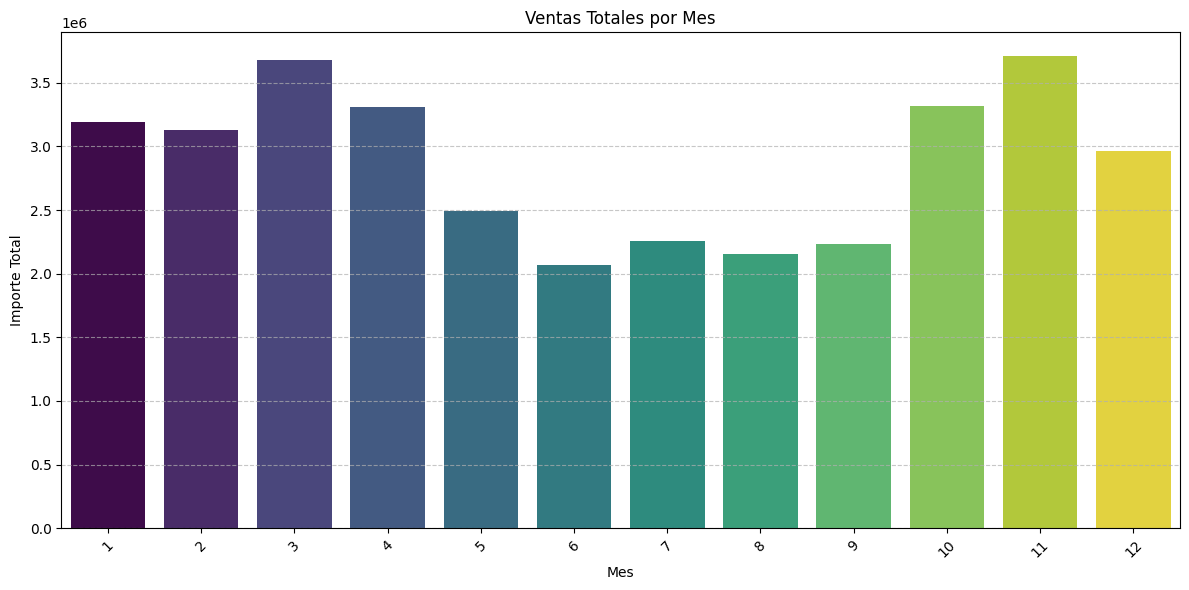

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupar ventas por mes, solo para documentos activos (Documento_Estado = 1)
ventas_mes_activos = df[df['Documento_Estado'] == 1].groupby('Mes')['Importe_Total'].sum().reset_index()

# Crear gráfico de barras
plt.figure(figsize=(12, 6))
sns.barplot(x='Mes', y='Importe_Total', hue='Mes', data=ventas_mes_activos, palette='viridis', legend=False)

# Títulos y etiquetas
plt.title('Ventas Totales por Mes')
plt.xlabel('Mes')
plt.ylabel('Importe Total')
plt.xticks(rotation=45) # Rotar etiquetas si es necesario
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar gráfico
plt.tight_layout()
plt.show()

***Top 10 Vendedores por Volumen de Ventas***



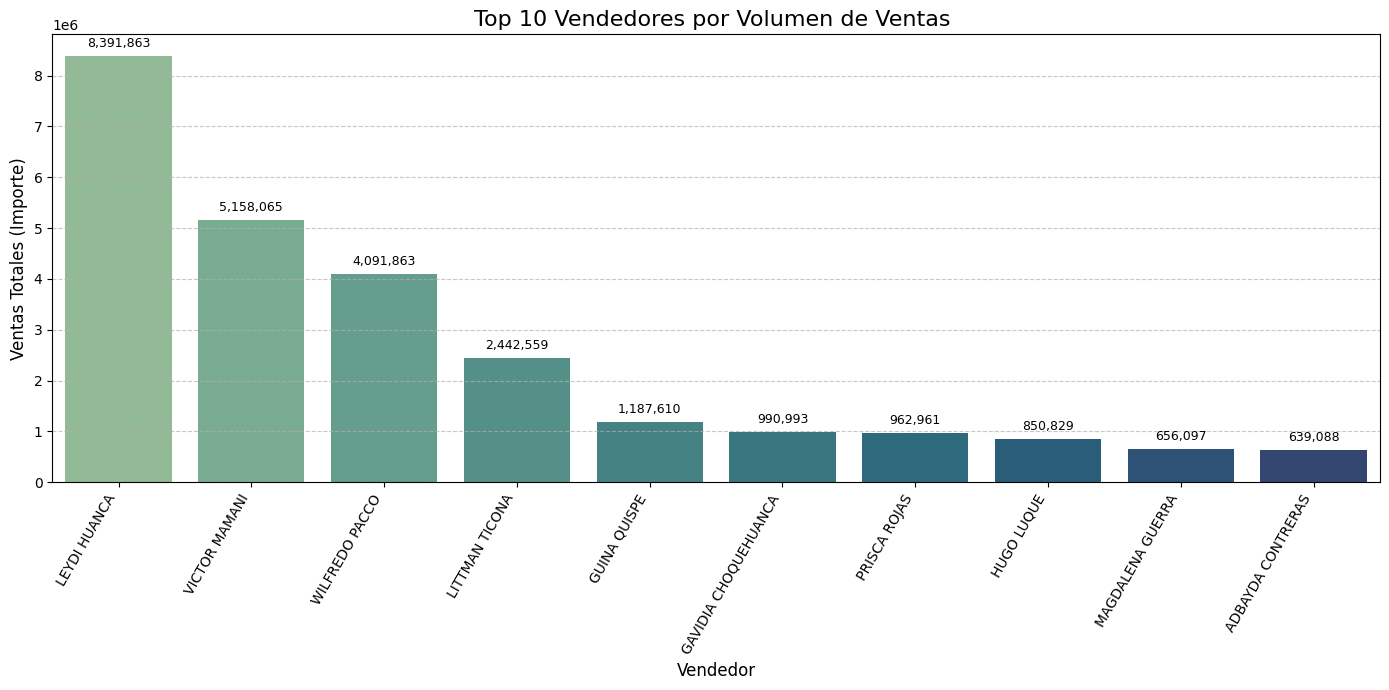

In [24]:
# Top vendedores (solo documentos activos)
top_vendedores = df[df['Documento_Estado'] == 1].groupby('Vendedor_Nombre')['Importe_Total'].sum()

# Ordenar y seleccionar el top 10
top_vendedores = top_vendedores.sort_values(ascending=False).head(10)

# Gráfico mejorado con Seaborn
plt.figure(figsize=(14, 7)) # Aumentar tamaño para mejor visibilidad
ax = sns.barplot(x=top_vendedores.index, y=top_vendedores.values,
                 palette='crest', hue=top_vendedores.index, legend=False)

# Títulos y etiquetas
plt.title('Top 10 Vendedores por Volumen de Ventas ', fontsize=16)
plt.xlabel('Vendedor', fontsize=12)
plt.ylabel('Ventas Totales (Importe)', fontsize=12)
plt.xticks(rotation=60, ha='right', fontsize=10) # Rotar más las etiquetas para evitar solapamiento
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Añadir etiquetas de valor a las barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}', # Formatear el número sin decimales y con comas
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=9)

plt.tight_layout() # Ajustar el diseño para evitar que las etiquetas se corten
plt.show()

***Gráfico de dispersión para comparar Importe y Mes***


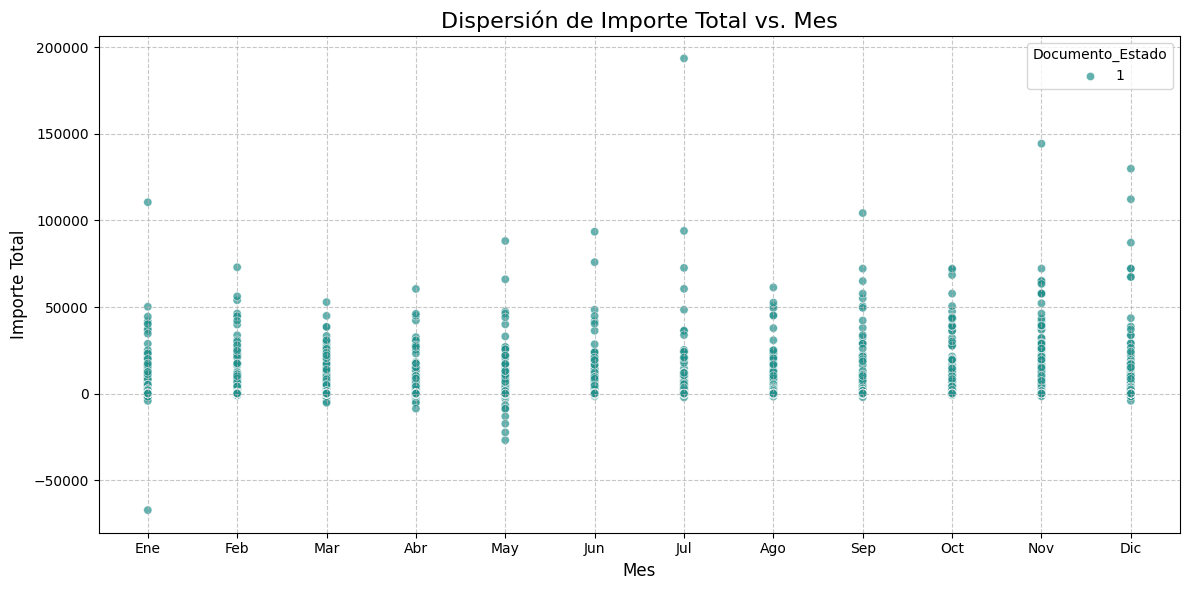

In [25]:
# Gráfico de dispersión para comparar Importe_Total y Mes (solo documentos activos)
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Mes', y='Importe_Total', hue='Documento_Estado', data=df[df['Documento_Estado'] == 1], palette='viridis', alpha=0.7)

# Títulos y etiquetas
plt.title('Dispersión de Importe Total vs. Mes', fontsize=16)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Importe Total', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(range(1, 13), ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']) # Etiquetas de meses más amigables

plt.tight_layout()
plt.show()

***Productos más vendidos***



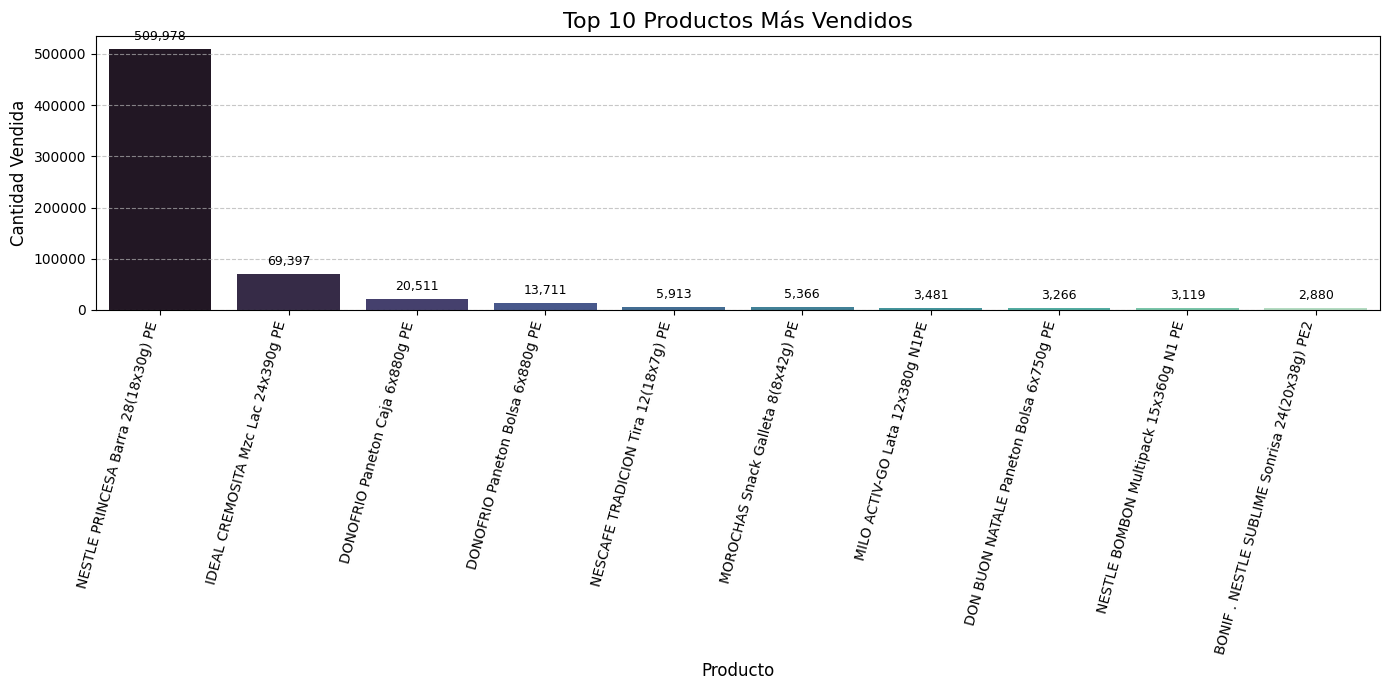

In [26]:
# 1. Aplicamos el filtro: Estado activo Y categoría distinta a 'Actividades'
filtro_productos = (df['Documento_Estado'] == 1) & (df['Categoria_detalle'] != 'ACTIVIDADES')

# 2. Agrupamos y sumamos
productos = df[filtro_productos].groupby('Producto_Detalle')['Producto_Cantidad'].sum()

# 3. Top 10
productos = productos.sort_values(ascending=False).head(10)

# --- El resto de tu código de visualización se mantiene igual ---
plt.figure(figsize=(14, 7))
ax = sns.barplot(x=productos.index, y=productos.values,
                 palette='mako', hue=productos.index, legend=False)

plt.title('Top 10 Productos Más Vendidos', fontsize=16)
plt.xlabel('Producto', fontsize=12)
plt.ylabel('Cantidad Vendida', fontsize=12)
plt.xticks(rotation=75, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=9)

plt.tight_layout()
plt.show()

***Top 10 Provincias con Mayor Volumen de Ventas***

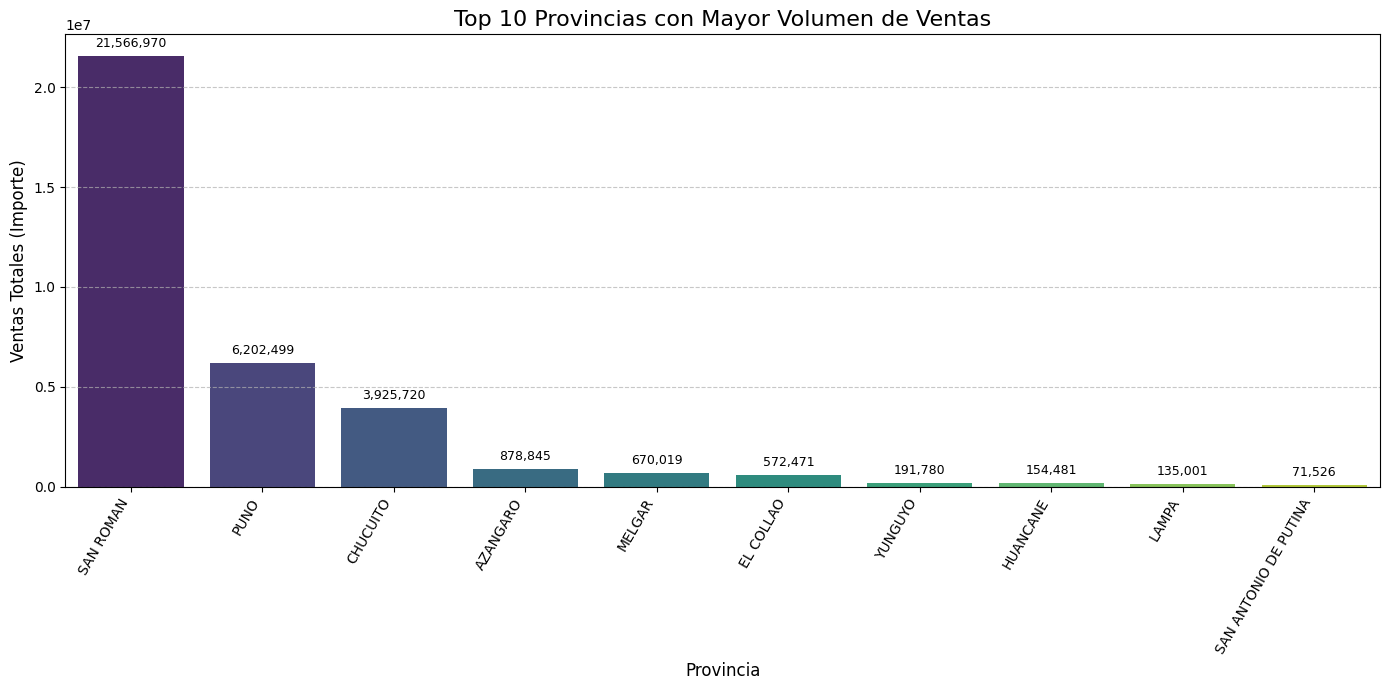

In [27]:
# Ventas por provincia
ventas_departamento = df[df['Documento_Estado'] == 1].groupby('Cliente_Provincia')['Importe_Total'].sum()

# Top provincia
ventas_departamento = ventas_departamento.sort_values(ascending=False).head(10)

# Gráfico mejorado con Seaborn
plt.figure(figsize=(14, 7)) # Aumentar tamaño para mejor visibilidad de etiquetas
ax = sns.barplot(x=ventas_departamento.index, y=ventas_departamento.values,
                 palette='viridis', hue=ventas_departamento.index, legend=False)

# Títulos y etiquetas
plt.title('Top 10 Provincias con Mayor Volumen de Ventas', fontsize=16)
plt.xlabel('Provincia', fontsize=12)
plt.ylabel('Ventas Totales (Importe)', fontsize=12)
plt.xticks(rotation=60, ha='right', fontsize=10) # Rotar más las etiquetas para evitar solapamiento
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Añadir etiquetas de valor a las barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}', # Formatear el número sin decimales y con comas
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=9)

plt.tight_layout() # Ajustar el diseño para evitar que las etiquetas se corten
plt.show()

In [28]:
print(f"El departamento con el mayor volumen de ventas es: {ventas_departamento.index[0]} con un total de {ventas_departamento.iloc[0]:,.2f}")

El departamento con el mayor volumen de ventas es: SAN ROMAN con un total de 21,566,969.81


***La categoría con el mayor volumen***

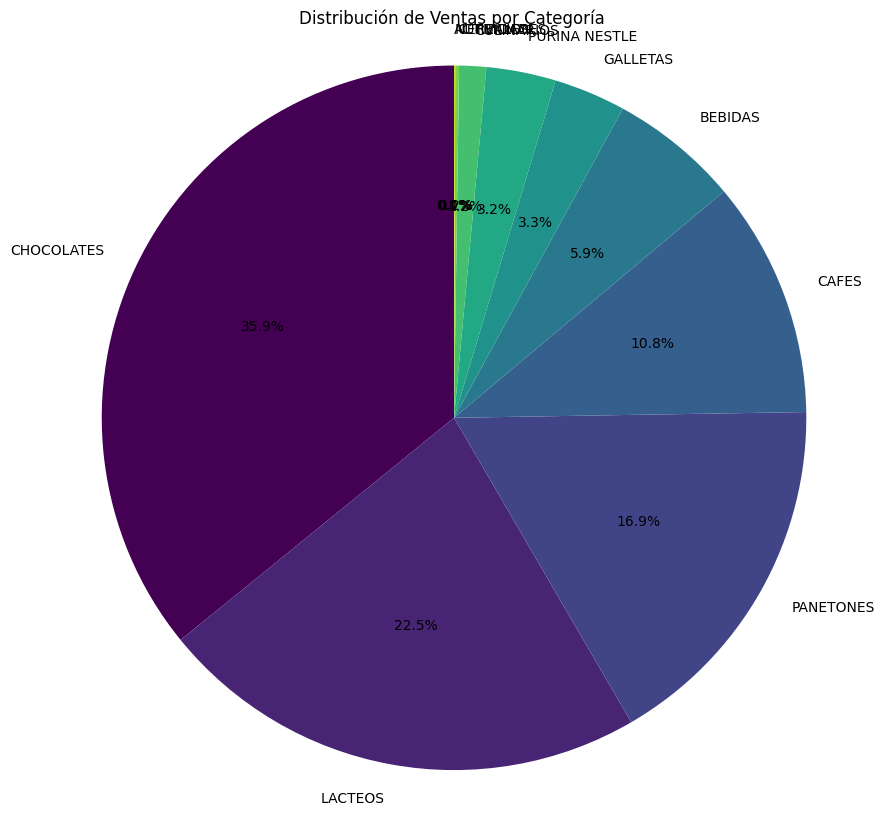

In [29]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 10))

# Calculate sales by category (only for active documents)
categorias = df[df['Documento_Estado'] == 1].groupby('Categoria_detalle')['Importe_Total'].sum().sort_values(ascending=False)

# Generar colores de la paleta 'viridis'
colors = plt.cm.viridis(np.linspace(0, 1, len(categorias.index)))

plt.pie(categorias.values, labels=categorias.index, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Distribución de Ventas por Categoría ')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [30]:
print(f"La categoría con el mayor volumen de ventas es: {categorias.index[0]} con un total de {categorias.iloc[0]:,.2f}")

La categoría con el mayor volumen de ventas es: CHOCOLATES con un total de 12,373,593.61


***Categoría más vendida por mes***

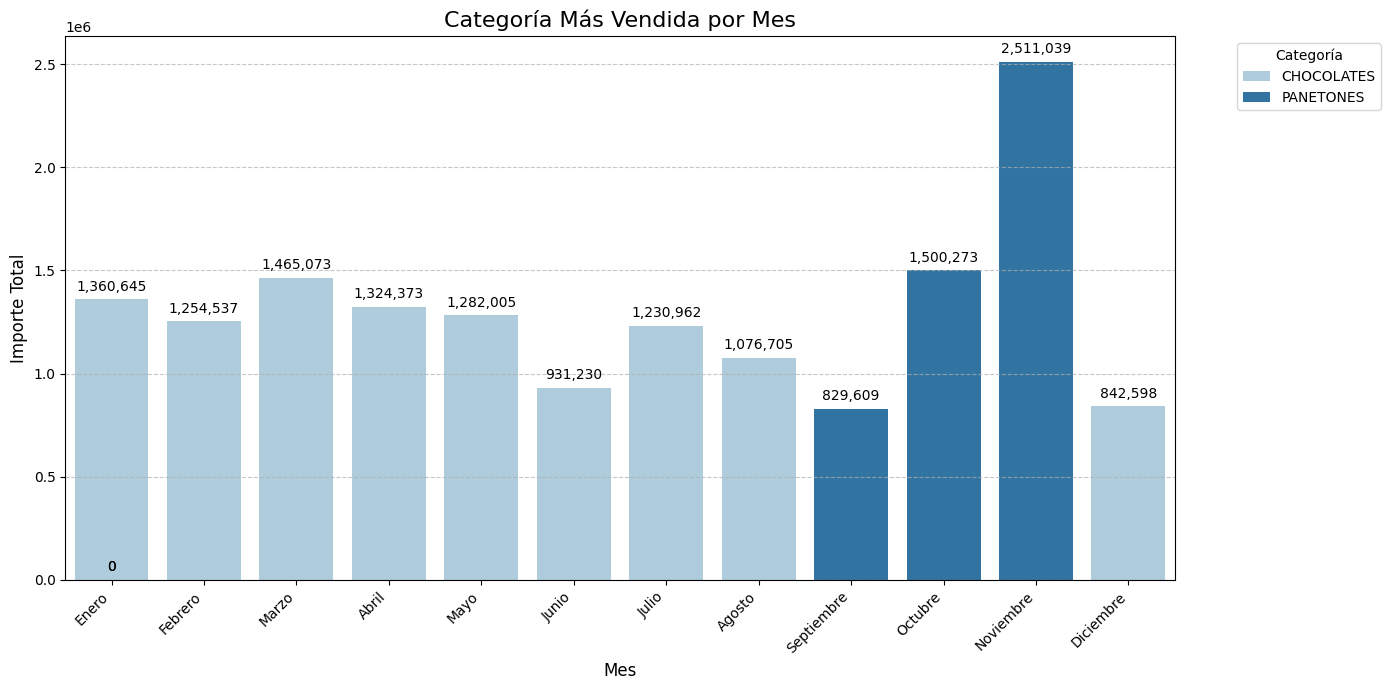

In [31]:
# Filtrar solo documentos activos
df_activos = df[df['Documento_Estado'] == 1]

# Agrupar por mes y categoría, y sumar el Importe_Total
ventas_por_mes_categoria = df_activos.groupby(['Mes', 'Categoria_detalle'])['Importe_Total'].sum().reset_index()

# Encontrar la categoría con mayor venta por cada mes
idx = ventas_por_mes_categoria.groupby('Mes')['Importe_Total'].idxmax()
mejor_categoria_por_mes = ventas_por_mes_categoria.loc[idx].reset_index(drop=True)

# Mapear los números de mes a nombres para una mejor visualización
month_names = {1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril', 5: 'Mayo', 6: 'Junio',
               7: 'Julio', 8: 'Agosto', 9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'}
mejor_categoria_por_mes['Mes_Nombre'] = mejor_categoria_por_mes['Mes'].map(month_names)

# Crear el gráfico de barras
plt.figure(figsize=(14, 7))
sns.barplot(x='Mes_Nombre', y='Importe_Total', hue='Categoria_detalle', data=mejor_categoria_por_mes, palette='Paired', dodge=False)

# Añadir etiquetas de valor a las barras
ax = plt.gca() # Get current axes
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=10)

plt.title('Categoría Más Vendida por Mes', fontsize=16)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Importe Total', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Categoría', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

***Categorías más vendida por mes en SAN ROMAN***

/tmp/ipykernel_9798/2499909794.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  san_roman_top_3_monthly = san_roman_data_grouped.groupby('Mes', group_keys=False).apply(lambda x: x.nlargest(3, 'Importe_Total')).reset_index(drop=True)


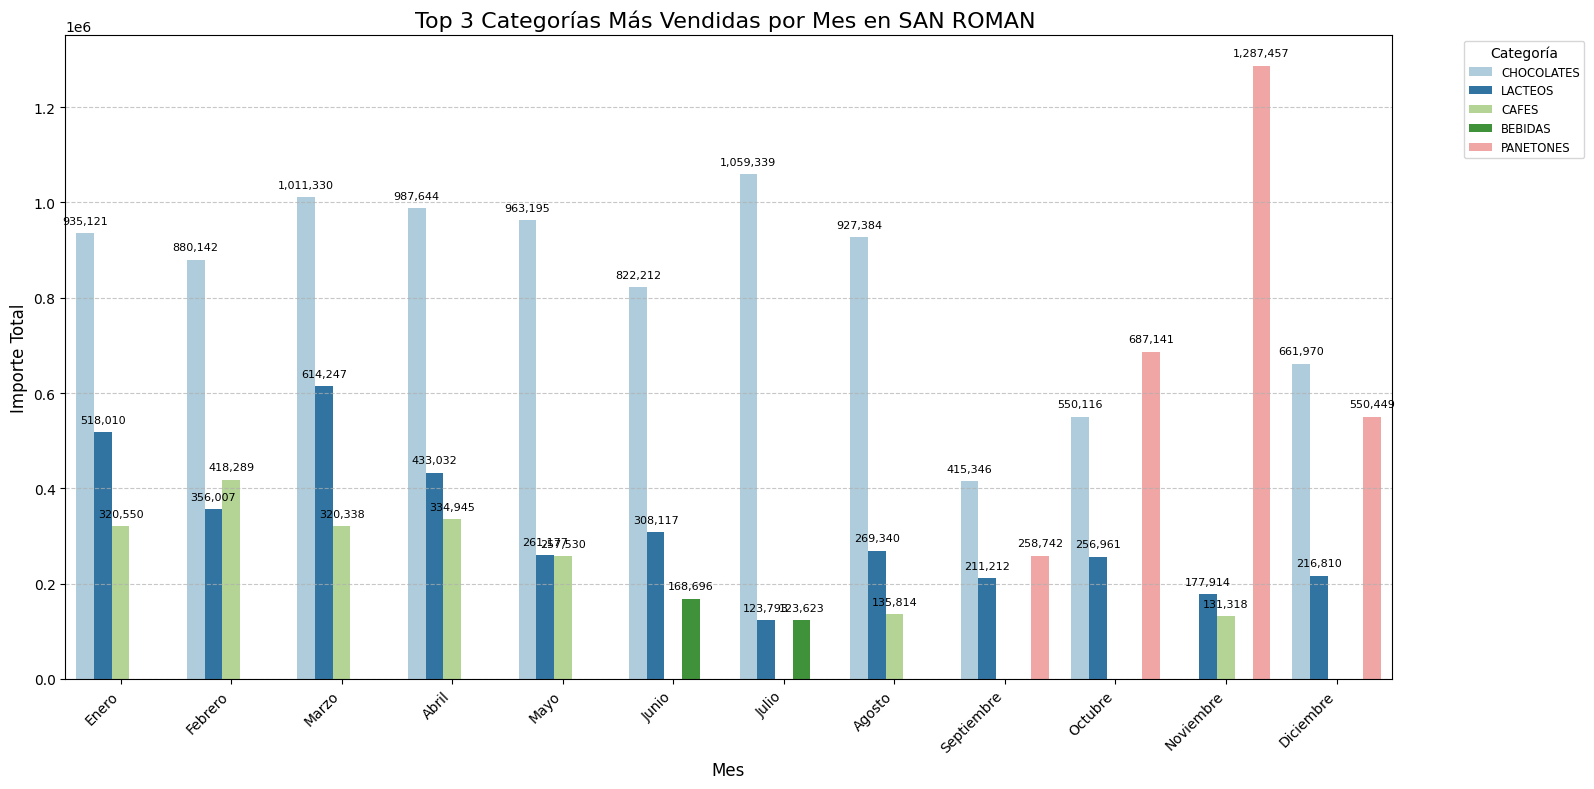

In [32]:
# Filtrar los datos para la provincia de SAN ROMAN y agrupar por mes y categoría
san_roman_data_grouped = df_activos[df_activos['Cliente_Provincia'] == 'SAN ROMAN'].groupby(['Mes', 'Categoria_detalle'])['Importe_Total'].sum().reset_index()

# Encontrar las top 3 categorías por mes en SAN ROMAN
san_roman_top_3_monthly = san_roman_data_grouped.groupby('Mes', group_keys=False).apply(lambda x: x.nlargest(3, 'Importe_Total')).reset_index(drop=True)

# Mapear los números de mes a nombres para una mejor visualización
month_names = {1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril', 5: 'Mayo', 6: 'Junio',
               7: 'Julio', 8: 'Agosto', 9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'}
san_roman_top_3_monthly['Mes_Nombre'] = san_roman_top_3_monthly['Mes'].map(month_names)

# Crear el gráfico de barras para SAN ROMAN con las top 3 categorías
plt.figure(figsize=(16, 8))
sns.barplot(x='Mes_Nombre', y='Importe_Total', hue='Categoria_detalle', data=san_roman_top_3_monthly, palette='Paired', dodge=True)

# Añadir etiquetas de valor a las barras
ax = plt.gca() # Get current axes
for p in ax.patches:
    if p.get_height() > 0: # Solo añadir etiquetas a barras con valor positivo
        ax.annotate(f'{p.get_height():,.0f}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points',
                    fontsize=8)

plt.title('Top 3 Categorías Más Vendidas por Mes en SAN ROMAN ', fontsize=16)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Importe Total', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Categoría', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

***Categorías más vendida por mes en Puno***

/tmp/ipykernel_9798/1867949272.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  puno_top_3_monthly = puno_data_grouped.groupby('Mes', group_keys=False).apply(lambda x: x.nlargest(3, 'Importe_Total')).reset_index(drop=True)


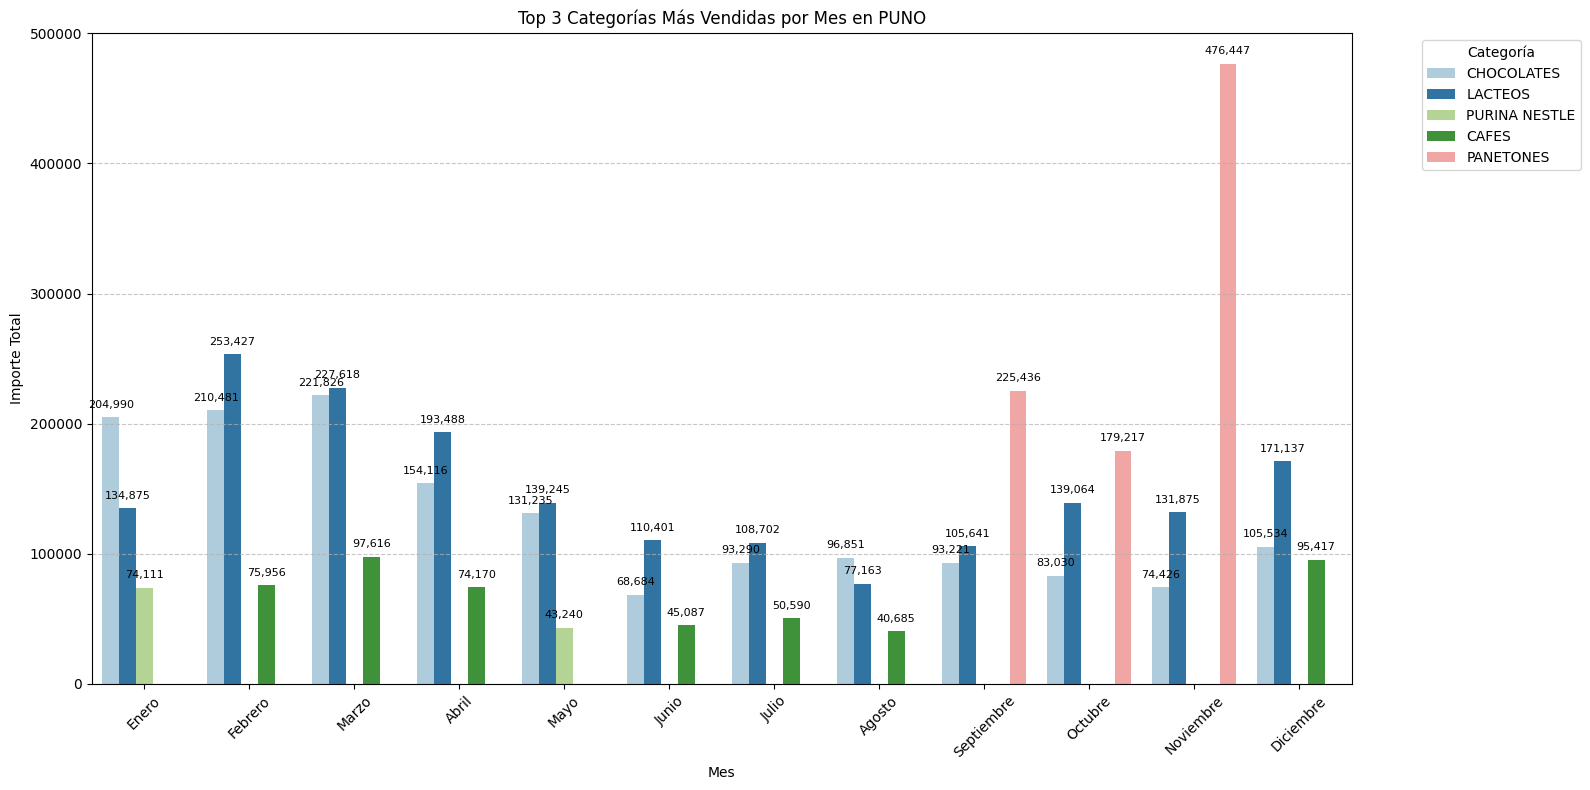

In [33]:
# Filtrar los datos para la provincia de PUNO y agrupar por mes y categoría
puno_data_grouped = df_activos[df_activos['Cliente_Provincia'] == 'PUNO'].groupby(['Mes', 'Categoria_detalle'])['Importe_Total'].sum().reset_index()

# Encontrar las top 3 categorías por mes en PUNO
puno_top_3_monthly = puno_data_grouped.groupby('Mes', group_keys=False).apply(lambda x: x.nlargest(3, 'Importe_Total')).reset_index(drop=True)

# Mapear números de mes a nombres
month_names = {
    1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril',
    5: 'Mayo', 6: 'Junio', 7: 'Julio', 8: 'Agosto',
    9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'
}

puno_top_3_monthly['Mes_Nombre'] = puno_top_3_monthly['Mes'].map(month_names)

# Crear gráfico
plt.figure(figsize=(16, 8))

sns.barplot(
    x='Mes_Nombre',
    y='Importe_Total',
    hue='Categoria_detalle',
    data=puno_top_3_monthly,
    palette='Paired'
)

# Etiquetas en barras
ax = plt.gca()

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(
            f'{p.get_height():,.0f}',
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center',
            va='center',
            xytext=(0, 9),
            textcoords='offset points',
            fontsize=8
        )

# Personalizar gráfico
plt.title('Top 3 Categorías Más Vendidas por Mes en PUNO')
plt.xlabel('Mes')
plt.ylabel('Importe Total')

plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.legend(title='Categoría', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

plt.show()

**Análisis de Pareto (Top 20 Productos)**




In [34]:
#SIGUIENTE ANALISIS

# 1. Carga optimizada (Usando solo lo necesario para este nivel)
cols = ['Periodo_Mes', 'Documento_Estado', 'Documento_Fecha', 'Producto_Detalle',
        'Producto_Cantidad', 'Importe_Total', 'Categoria_detalle', 'Vendedor_Nombre', 'Cliente_Provincia', 'Cliente_Categoria']

df = pd.read_csv('/content/drive/MyDrive/CD/ventas2025.csv', sep=';', usecols=cols)

# 2. Limpieza básica y corrección de tipos
df['Documento_Estado'] = df['Documento_Estado'].replace({'ACTIVO': 1, 'ANULADO': 0}).astype(int)
df_activos = df[df['Documento_Estado'] == 1].copy()

/tmp/ipykernel_9798/3245002544.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Documento_Estado'] = df['Documento_Estado'].replace({'ACTIVO': 1, 'ANULADO': 0}).astype(int)


Top 10 productos por ventas acumuladas:
                          Producto_Detalle        Ventas  Ventas_Acumuladas  \
0       IDEAL CREMOSITA Mzc Lac 24x390g PE  5.908508e+06       5.908508e+06   
1          DONOFRIO Paneton Caja 6x880g PE  2.979688e+06       8.888197e+06   
2     NESTLE SUBLIME Sonrisa 24(20x38g) PE  2.252290e+06       1.114049e+07   
3     NESTLE SUBLIME Sonrisa 24(20x37g) PE  1.853580e+06       1.299407e+07   
4         DONOFRIO Paneton Bolsa 6x880g PE  1.811424e+06       1.480549e+07   
5      NESCAFE TRADICION Tira 12(18x7g) PE  1.545918e+06       1.635141e+07   
6   NESTLE TRIANGULO Clasico 24(20x30g) PE  1.279262e+06       1.763067e+07   
7   NESTLE TRIANGULO Clasico 24(20x29g) PE  1.073504e+06       1.870418e+07   
8      NESTLE PRINCESA Barra 28(18x30g) PE  1.033396e+06       1.973757e+07   
9  NESTLE SUBLIME SonrisaBla 24(20x38g) PE  1.012952e+06       2.075052e+07   

   Porcentaje_Acumulado  
0             17.123972  
1             25.759671  
2           

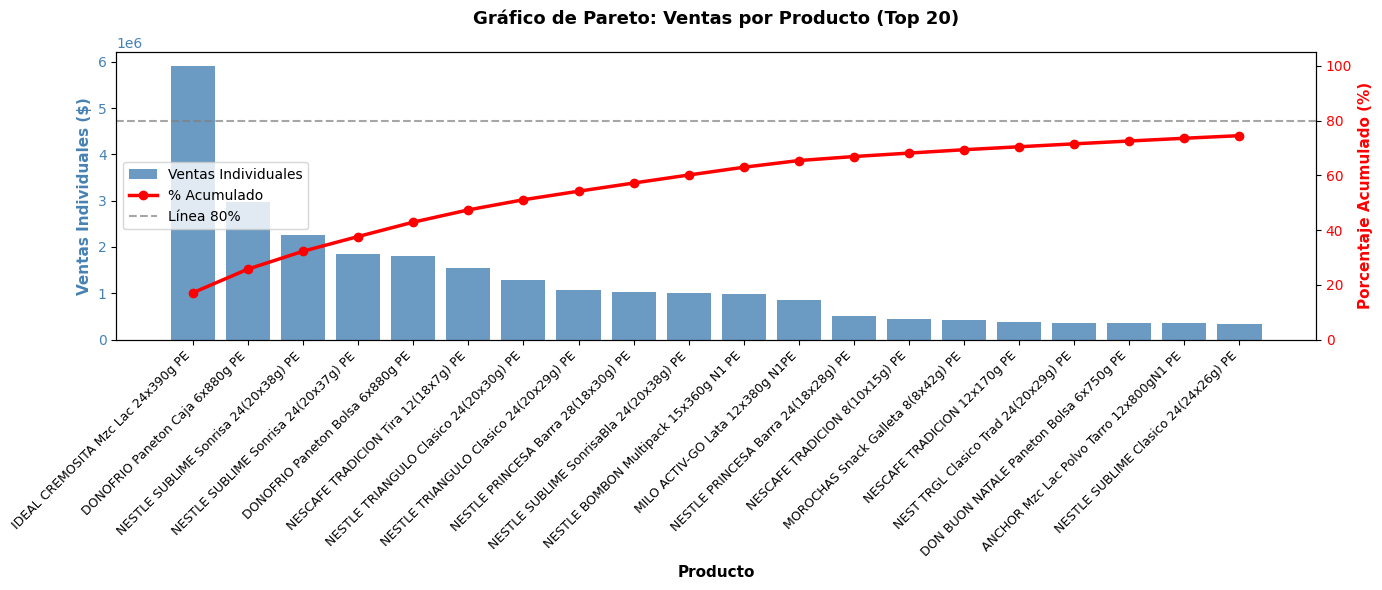


Total de productos: 603
Total de ventas: $34,504,310.60

Top 5 productos con mayor ingreso:
                    Producto_Detalle       Ventas  Porcentaje_Acumulado
  IDEAL CREMOSITA Mzc Lac 24x390g PE 5.908508e+06             17.123972
     DONOFRIO Paneton Caja 6x880g PE 2.979688e+06             25.759671
NESTLE SUBLIME Sonrisa 24(20x38g) PE 2.252290e+06             32.287231
NESTLE SUBLIME Sonrisa 24(20x37g) PE 1.853580e+06             37.659257
    DONOFRIO Paneton Bolsa 6x880g PE 1.811424e+06             42.909106


In [37]:
# Calcular ingreso acumulado por Producto_Detalle
ventas_por_producto = df_activos.groupby('Producto_Detalle')['Importe_Total'].sum().reset_index()
ventas_por_producto.columns = ['Producto_Detalle', 'Ventas']

# Ordenar descendentemente
ventas_por_producto = ventas_por_producto.sort_values('Ventas', ascending=False).reset_index(drop=True)

# Calcular ventas acumuladas
ventas_por_producto['Ventas_Acumuladas'] = ventas_por_producto['Ventas'].cumsum()

# Calcular porcentaje acumulado
total_ventas = ventas_por_producto['Ventas'].sum()
ventas_por_producto['Porcentaje_Acumulado'] = (ventas_por_producto['Ventas_Acumuladas'] / total_ventas) * 100

print("Top 10 productos por ventas acumuladas:")
print(ventas_por_producto.head(10))

# Crear gráfico de Pareto con Matplotlib (dos ejes Y)
fig, ax1 = plt.subplots(figsize=(14, 6))

# Limitar a los 20 productos principales para mejor visualización
productos_top = ventas_por_producto.head(20)

# Eje 1 (izquierdo): Barras de ventas individuales
x = range(len(productos_top))
bars = ax1.bar(x, productos_top['Ventas'], color='steelblue', alpha=0.8, label='Ventas Individuales')
ax1.set_xlabel('Producto', fontsize=11, fontweight='bold')
ax1.set_ylabel('Ventas Individuales ($)', fontsize=11, fontweight='bold', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_xticks(x)
ax1.set_xticklabels(productos_top['Producto_Detalle'], rotation=45, ha='right', fontsize=9)

# Eje 2 (derecho): Línea de porcentaje acumulado
ax2 = ax1.twinx()
line = ax2.plot(x, productos_top['Porcentaje_Acumulado'], color='red', marker='o',
                linewidth=2.5, markersize=6, label='% Acumulado')
ax2.set_ylabel('Porcentaje Acumulado (%)', fontsize=11, fontweight='bold', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 105)

# Agregar línea de referencia en 80%
ax2.axhline(y=80, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, label='Línea 80%')

# Título y leyenda
plt.title('Gráfico de Pareto: Ventas por Producto (Top 20)', fontsize=13, fontweight='bold', pad=20)
fig.tight_layout()

# Combinar leyendas de ambos ejes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left', fontsize=10)

plt.show()

# Estadísticas del Pareto
print(f"\nTotal de productos: {len(ventas_por_producto)}")
print(f"Total de ventas: ${total_ventas:,.2f}")
print(f"\nTop 5 productos con mayor ingreso:")
print(ventas_por_producto[['Producto_Detalle', 'Ventas', 'Porcentaje_Acumulado']].head(5).to_string(index=False))

**Comparativa: Ticket Promedio por Provincia vs Promedio General**



In [38]:
# Calcular Ticket Promedio por Provincia
ticket_por_provincia = df_activos.groupby('Cliente_Provincia')['Importe_Total'].mean().reset_index()
ticket_por_provincia.columns = ['Provincia', 'Ticket_Promedio']

# Filtrar solo PUNO y SAN ROMAN
provincias_comparar = ticket_por_provincia[ticket_por_provincia['Provincia'].isin(['PUNO', 'SAN ROMAN'])]

# Calcular promedio general
promedio_general = df_activos['Importe_Total'].mean()

print("Ticket Promedio por Provincia (PUNO y SAN ROMAN):")
print(provincias_comparar.to_string(index=False))
print(f"\nPromedio General del Dataset: ${promedio_general:.2f}")
print(f"\nPUNO: {'✓ Por ENCIMA' if provincias_comparar[provincias_comparar['Provincia']=='PUNO']['Ticket_Promedio'].values[0] > promedio_general else '✗ Por DEBAJO'} de la media")
print(f"SAN ROMAN: {'✓ Por ENCIMA' if provincias_comparar[provincias_comparar['Provincia']=='SAN ROMAN']['Ticket_Promedio'].values[0] > promedio_general else '✗ Por DEBAJO'} de la media")

Ticket Promedio por Provincia (PUNO y SAN ROMAN):
Provincia  Ticket_Promedio
     PUNO        56.475177
SAN ROMAN        82.708439

Promedio General del Dataset: $81.34

PUNO: ✗ Por DEBAJO de la media
SAN ROMAN: ✓ Por ENCIMA de la media


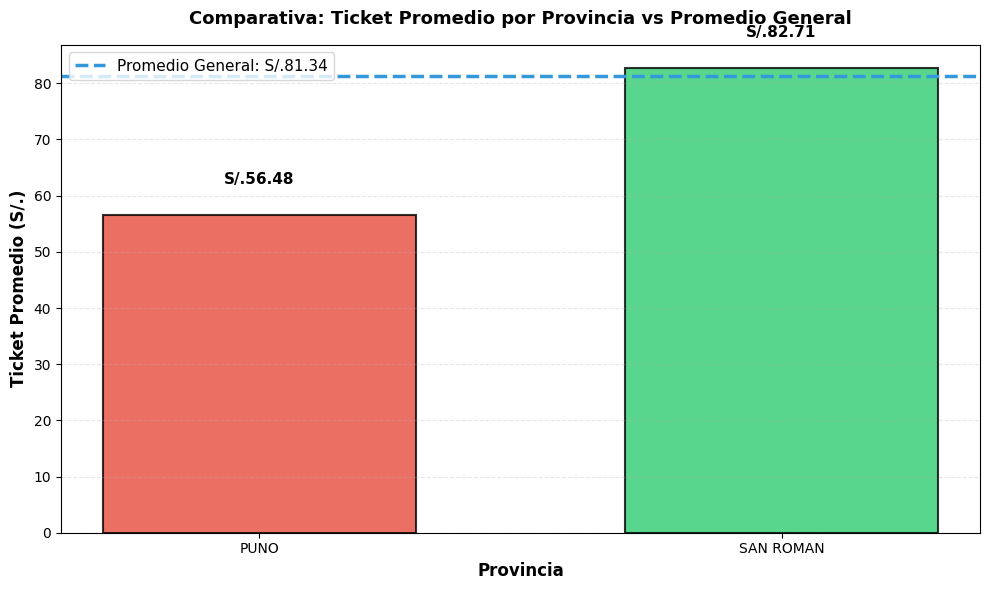


Interpretación:
  PUNO: S/.24.87 MENOS (-30.6%) que el promedio
  SAN ROMAN: S/.1.37 MÁS (+1.7%) que el promedio


In [39]:
# Gráfico de barras: Ticket Promedio por Provincia
fig, ax = plt.subplots(figsize=(10, 6))

# Datos para el gráfico
provincias = provincias_comparar['Provincia'].values
tickets = provincias_comparar['Ticket_Promedio'].values

# Crear barras
colors = ['#2ecc71' if ticket > promedio_general else '#e74c3c' for ticket in tickets]
bars = ax.bar(provincias, tickets, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5, width=0.6)

# Agregar línea horizontal del promedio general
ax.axhline(y=promedio_general, color='#3498db', linestyle='--', linewidth=2.5, label=f'Promedio General: S/.{promedio_general:.2f}')

# Etiquetas y título
ax.set_ylabel('Ticket Promedio (S/.)', fontsize=12, fontweight='bold')
ax.set_xlabel('Provincia', fontsize=12, fontweight='bold')
ax.set_title('Comparativa: Ticket Promedio por Provincia vs Promedio General', fontsize=13, fontweight='bold', pad=15)

# Añadir valores en las barras
for i, (provincia, ticket) in enumerate(zip(provincias, tickets)):
    ax.text(i, ticket + 5, f'S/.{ticket:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Agregar leyenda
ax.legend(fontsize=11, loc='upper left')

# Grid para mejor lectura
ax.grid(True, axis='y', alpha=0.3, linestyle='--')

# Ajustar layout
plt.tight_layout()
plt.show()

print("\nInterpretación:")
for provincia, ticket in zip(provincias, tickets):
    diferencia = ticket - promedio_general
    porcentaje = (diferencia / promedio_general) * 100
    if diferencia > 0:
        print(f"  {provincia}: S/.{diferencia:.2f} MÁS (+{porcentaje:.1f}%) que el promedio")
    else:
        print(f"  {provincia}: S/.{abs(diferencia):.2f} MENOS ({porcentaje:.1f}%) que el promedio")

***Ticket Promedio - Volumen***

In [40]:
# Calcular Ticket Promedio por Cliente_Categoria
ticket_por_categoria = df_activos.groupby('Cliente_Categoria').agg({
    'Importe_Total': ['mean', 'count', 'sum']
}).reset_index()

# Simplificar nombres de columnas
ticket_por_categoria.columns = ['Cliente_Categoria', 'Ticket_Promedio', 'Cantidad_Transacciones', 'Ingreso_Total']

# Ordenar por ticket promedio descendente
ticket_por_categoria = ticket_por_categoria.sort_values('Ticket_Promedio', ascending=False)

print("=" * 70)
print("TICKET PROMEDIO POR CATEGORÍA DE CLIENTE")
print("=" * 70)
print(ticket_por_categoria.to_string(index=False))

print("\n" + "=" * 70)
print("ANÁLISIS:")
print("=" * 70)
for idx, row in ticket_por_categoria.iterrows():
    print(f"\n{row['Cliente_Categoria']}:")
    print(f"  • Ticket Promedio: S/.{row['Ticket_Promedio']:.2f}")
    print(f"  • Transacciones: {int(row['Cantidad_Transacciones'])}")
    print(f"  • Ingreso Total: S/.{row['Ingreso_Total']:,.2f}")

# Calcular diferencia
if len(ticket_por_categoria) > 1:
    mayor = ticket_por_categoria.iloc[0]
    menor = ticket_por_categoria.iloc[-1]
    diferencia = mayor['Ticket_Promedio'] - menor['Ticket_Promedio']
    porcentaje_diff = (diferencia / menor['Ticket_Promedio']) * 100
    print(f"\n→ Diferencia entre {mayor['Cliente_Categoria']} y {menor['Cliente_Categoria']}: S/.{diferencia:.2f} (+{porcentaje_diff:.1f}%)")

TICKET PROMEDIO POR CATEGORÍA DE CLIENTE
    Cliente_Categoria  Ticket_Promedio  Cantidad_Transacciones  Ingreso_Total
            MAYORISTA      2210.950095                    5978   1.321706e+07
MAYORISTA - PROVINCIA      2032.386682                    2257   4.587097e+06
       ESPECIALIZADOS       366.881702                    1769   6.490137e+05
              MERCADO        74.172021                   29878   2.216112e+06
             EMPLEADO        41.494524                     178   7.386025e+03
MINORISTA - PROVINCIA        37.762628                   53349   2.014598e+06
            MINORISTA        35.716345                  330648   1.180954e+07
  MERCADO - PROVINCIA        26.972177                     130   3.506383e+03

ANÁLISIS:

MAYORISTA:
  • Ticket Promedio: S/.2210.95
  • Transacciones: 5978
  • Ingreso Total: S/.13,217,059.67

MAYORISTA - PROVINCIA:
  • Ticket Promedio: S/.2032.39
  • Transacciones: 2257
  • Ingreso Total: S/.4,587,096.74

ESPECIALIZADOS:
  • Ticket

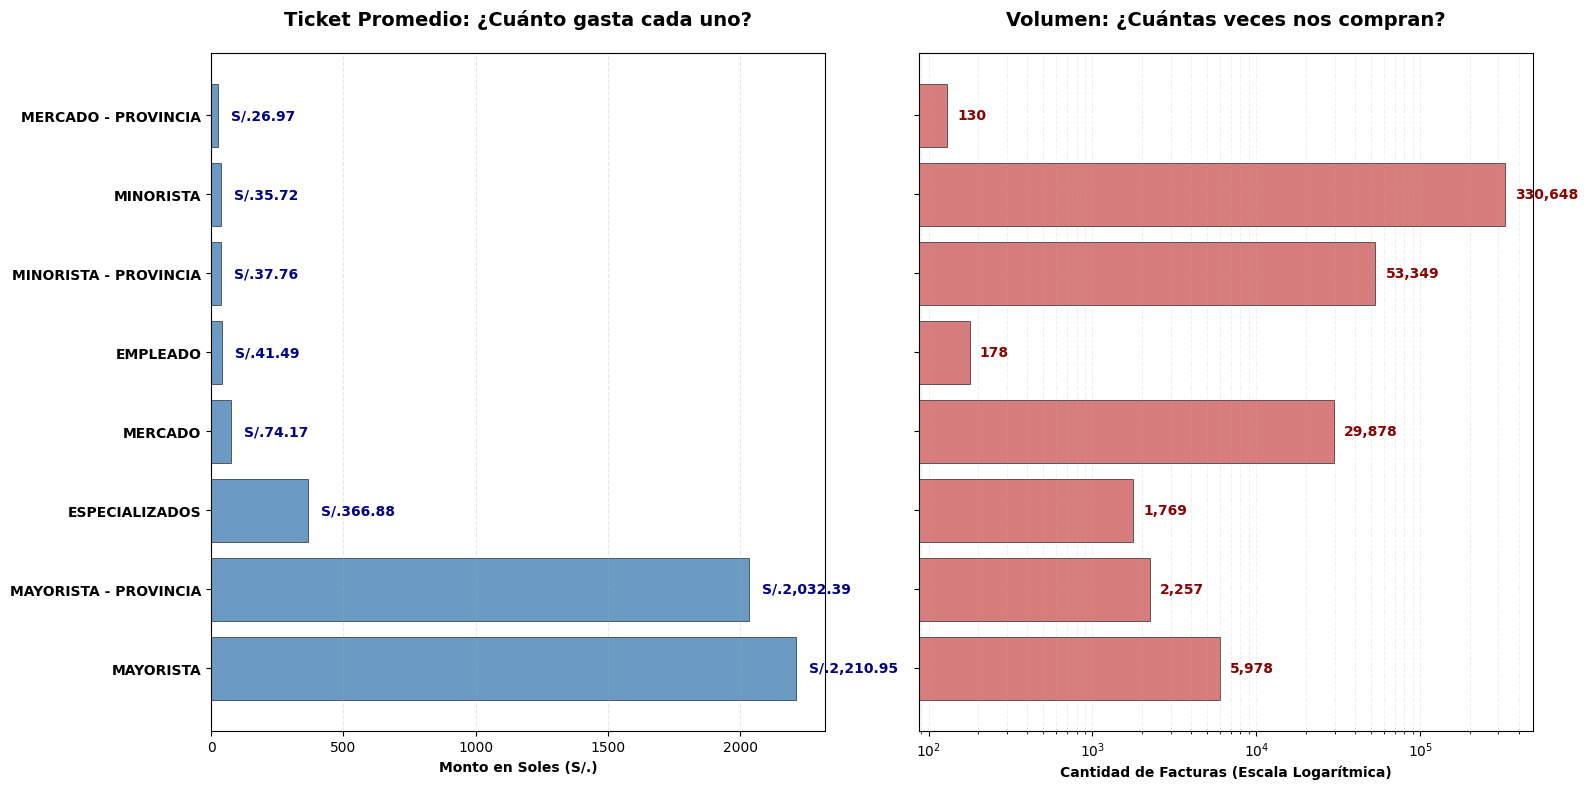

In [41]:
# 1. Configuramos el lienzo (Dos gráficos horizontales)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
plt.style.use('bmh') # Estilo limpio y profesional

# 2. GRÁFICO DE VALOR: Barras horizontales para leer bien los nombres
y_pos = range(len(ticket_por_categoria))
tickets = ticket_por_categoria['Ticket_Promedio'].values
nombres = ticket_por_categoria['Cliente_Categoria'].values

ax1.barh(y_pos, tickets, color='steelblue', edgecolor='black', alpha=0.8)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(nombres, fontsize=10, fontweight='bold')
ax1.set_xlabel('Monto en Soles (S/.)', fontweight='bold')
ax1.set_title('Ticket Promedio: ¿Cuánto gasta cada uno?', fontsize=14, fontweight='bold', pad=20)
ax1.grid(True, axis='x', alpha=0.3, linestyle='--')

# Añadir los valores al final de cada barra
for i, v in enumerate(tickets):
    ax1.text(v + 50, i, f'S/.{v:,.2f}', va='center', fontweight='bold', color='darkblue')

# 3. GRÁFICO DE VOLUMEN: Con escala LOGARÍTMICA
volumen = ticket_por_categoria['Cantidad_Transacciones'].values

ax2.barh(y_pos, volumen, color='indianred', edgecolor='black', alpha=0.8)
ax2.set_yticks(y_pos)
ax2.set_yticklabels([]) # Quitamos nombres aquí para no repetir y ganar espacio
ax2.set_xscale('log') # CRUCIAL: Para ver 130 y 330,000 al mismo tiempo
ax2.set_xlabel('Cantidad de Facturas (Escala Logarítmica)', fontweight='bold')
ax2.set_title('Volumen: ¿Cuántas veces nos compran?', fontsize=14, fontweight='bold', pad=20)
ax2.grid(True, axis='x', which="both", alpha=0.2, linestyle='--')

# Añadir la cantidad total al final
for i, v in enumerate(volumen):
    ax2.text(v * 1.15, i, f'{int(v):,}', va='center', fontweight='bold', color='darkred')

plt.tight_layout()
plt.show()

  **Jerarquia de Clientes**

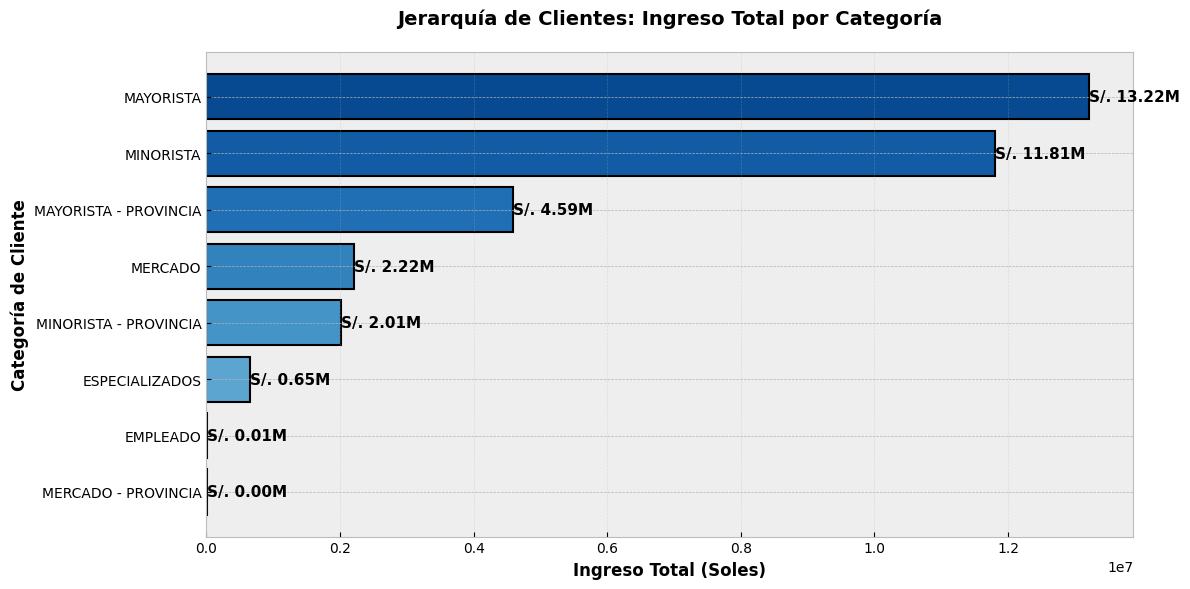

ANÁLISIS DE JERARQUÍA DE CLIENTES - INGRESO POR CATEGORÍA
            Categoría  Ingreso Total (S/.)  Ingreso (Millones)  Porcentaje del Total
            MAYORISTA         1.321706e+07           13.217060             38.305532
            MINORISTA         1.180954e+07           11.809538             34.226268
MAYORISTA - PROVINCIA         4.587097e+06            4.587097             13.294272
              MERCADO         2.216112e+06            2.216112              6.422710
MINORISTA - PROVINCIA         2.014598e+06            2.014598              5.838686
       ESPECIALIZADOS         6.490137e+05            0.649014              1.880964
             EMPLEADO         7.386025e+03            0.007386              0.021406
  MERCADO - PROVINCIA         3.506383e+03            0.003506              0.010162

ESTADÍSTICAS CLAVE

Categoría con MAYOR INGRESO: MAYORISTA
  → Ingreso Total: S/. 13,217,059.67
  → En Millones: S/. 13.22M
  → Representa el 38.31% del ingreso total

Ingreso 

In [42]:

# 1. Agrupar por Cliente_Categoria y sumar Importe_Total
ingreso_por_categoria = df_activos.groupby('Cliente_Categoria')['Importe_Total'].sum().sort_values(ascending=True)

# 2. Crear figura con gráfico de barras horizontales
plt.figure(figsize=(12, 6))
plt.style.use('bmh')

# Colores degradados para mejor visualización
colors_gradient = plt.cm.Blues(np.linspace(0.4, 0.9, len(ingreso_por_categoria)))

# Crear barras horizontales
bars = plt.barh(ingreso_por_categoria.index, ingreso_por_categoria.values, color=colors_gradient, edgecolor='black', linewidth=1.5)

# 3. Calcular valores en millones para las etiquetas
valores_millones = ingreso_por_categoria.values / 1_000_000
total_ingreso = ingreso_por_categoria.sum()
porcentaje_categoria_top = (ingreso_por_categoria.max() / total_ingreso) * 100

# 4. Agregar etiquetas de valor en formato "S/. Millones"
for i, (bar, valor_millon) in enumerate(zip(bars, valores_millones)):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'S/. {valor_millon:.2f}M',
             va='center', fontsize=11, fontweight='bold')

# 5. Configurar etiquetas y título
plt.xlabel('Ingreso Total (Soles)', fontsize=12, fontweight='bold')
plt.ylabel('Categoría de Cliente', fontsize=12, fontweight='bold')
plt.title('Jerarquía de Clientes: Ingreso Total por Categoría', fontsize=14, fontweight='bold', pad=20)
plt.grid(True, axis='x', alpha=0.3, linestyle='--')

# Ajustar layout para que las etiquetas se vean bien
plt.tight_layout()
plt.show()

# 6. Mostrar análisis detallado
print("=" * 80)
print("ANÁLISIS DE JERARQUÍA DE CLIENTES - INGRESO POR CATEGORÍA")
print("=" * 80)

# Crear DataFrame para mejor visualización
resultado_categoria = pd.DataFrame({
    'Categoría': ingreso_por_categoria.index,
    'Ingreso Total (S/.)': ingreso_por_categoria.values,
    'Ingreso (Millones)': valores_millones,
    'Porcentaje del Total': (ingreso_por_categoria.values / total_ingreso * 100)
}).sort_values('Ingreso Total (S/.)', ascending=False).reset_index(drop=True)

print(resultado_categoria.to_string(index=False))

print("\n" + "=" * 80)
print("ESTADÍSTICAS CLAVE")
print("=" * 80)
categoria_top = resultado_categoria.iloc[0]
print(f"\nCategoría con MAYOR INGRESO: {categoria_top['Categoría']}")
print(f"  → Ingreso Total: S/. {categoria_top['Ingreso Total (S/.)']:,.2f}")
print(f"  → En Millones: S/. {categoria_top['Ingreso (Millones)']:.2f}M")
print(f"  → Representa el {categoria_top['Porcentaje del Total']:.2f}% del ingreso total")

print(f"\nIngreso Total General: S/. {total_ingreso:,.2f}")
print(f"Ingreso Total en Millones: S/. {total_ingreso/1_000_000:.2f}M")

**Mapa de comportomaineto de compra**

In [43]:
df_activos['Importe_Unitario'] = np.where(
    df_activos['Producto_Cantidad'] != 0,
    df_activos['Importe_Total'] / df_activos['Producto_Cantidad'],
    0
)

# 2. Verificamos que ahora sí exista
print(f"Columna creada. Nuevo listado: {df_activos.columns.tolist()}")

Columna creada. Nuevo listado: ['Periodo_Mes', 'Documento_Estado', 'Documento_Fecha', 'Cliente_Categoria', 'Categoria_detalle', 'Producto_Detalle', 'Producto_Cantidad', 'Importe_Total', 'Vendedor_Nombre', 'Cliente_Provincia', 'Importe_Unitario']


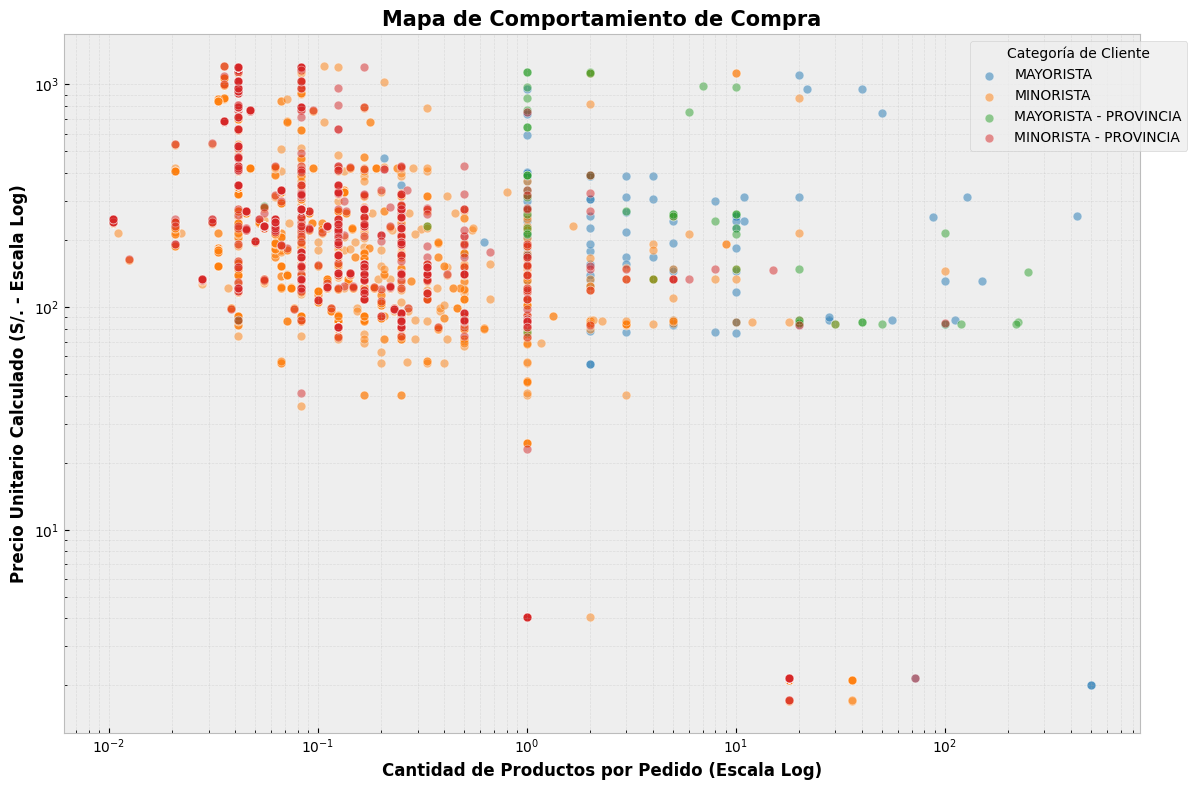

In [44]:
# Filtramos datos coherentes para el gráfico
df_scatter = df_activos[(df_activos['Importe_Unitario'] > 0) & (df_activos['Producto_Cantidad'] > 0)].copy()

# Tomamos muestra para rendimiento
df_sample = df_scatter.sample(n=min(10000, len(df_scatter)), random_state=42)

plt.figure(figsize=(12, 8))
plt.style.use('bmh')

# Colores por categoría
categorias_interes = ['MAYORISTA', 'MINORISTA', 'MAYORISTA - PROVINCIA', 'MINORISTA - PROVINCIA']
colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for cat, color in zip(categorias_interes, colores):
    subset = df_sample[df_sample['Cliente_Categoria'] == cat]
    plt.scatter(subset['Producto_Cantidad'], subset['Importe_Unitario'],
                alpha=0.5, label=cat, c=color, s=40, edgecolors='white', linewidth=0.5)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Cantidad de Productos por Pedido (Escala Log)', fontweight='bold')
plt.ylabel('Precio Unitario Calculado (S/. - Escala Log)', fontweight='bold')
plt.title('Mapa de Comportamiento de Compra', fontsize=15, fontweight='bold')
plt.legend(title='Categoría de Cliente', bbox_to_anchor=(1.05, 1))
plt.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()